In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import math
import boto3

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

(CVXPY) Jan 31 07:36:13 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jan 31 07:36:13 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def target_by_data_set(df, str_target):
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        str_target: 'mean',
    })
    df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
    df_tmp.sort_values(by='sort', ascending=True, inplace=True)
    df_tmp.drop('sort', axis=1, inplace=True)

    # plot
    x = df_tmp['data_set']
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by Data Set')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [3]:
def target_by_feature(df, str_col, str_target):
    df_tmp = df[df['data_set'] == 'train'].groupby(by=str_col, as_index=False).agg({
        str_target: 'mean',
    })

    # plot
    x = df_tmp[str_col].astype(str)
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_col}')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [4]:
def target_by_feature_quantile(df, str_col, int_n_quantiles, str_target):
    # get quantile
    df_tmp = df[df['data_set'] == 'train'].copy()
    # replace infs with nan
    df_tmp[str_col] = df_tmp[str_col].replace(np.inf, np.nan)
    # drop missing rows
    df_tmp = df_tmp.dropna(subset=[str_col])
    # get quantile
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], q=int_n_quantiles, duplicates='drop')
    # min-max
    df_tmp['min'] = df_tmp[str_col]
    df_tmp['max'] = df_tmp[str_col]
    # get target mean by quangtile
    df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'max': 'max',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'{str_target} by {str_col} Quantile')
    ax.set_xlabel(f'{str_col} Quantile')
    ax.set_ylabel(str_target)
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target])
    plt.show()

In [5]:
class OverSampling:
    def __init__(self, df, str_target, flt_target_value, flt_current_value):
        self.df = df
        self.str_target = str_target
        self.flt_target_value = flt_target_value
        self.flt_current_value = flt_current_value
    # oversample zeros
    def oversample_zeros(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for the new n total to reach target
        int_n_total_new = math.ceil(int_n_ones_original / flt_target_value)
        # get n additional 0s
        int_n_additional_zeros = int_n_total_new - int_n_ones_original - int_n_zeros_original
        # get sample
        df_zeros_additional = df_zeros.sample(n=int_n_additional_zeros, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_zeros_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df 
    # undersample ones
    def oversample_ones(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for number of 1s
        int_n_additional_ones = math.ceil((int_n_ones_original - (flt_target_value * int_n_total_original)) / (flt_target_value - 1))
        # get sample
        df_ones_additional = df_ones.sample(n=int_n_additional_ones, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_ones_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df
    # sample
    def sample(self):
        # logic
        if self.flt_target_value < self.flt_current_value:
            df = self.oversample_zeros()
        else:
            df = self.oversample_ones()
        # return
        return df

In [6]:
def get_logistic_regression_feat_importance(df, cls_model_inference, list_cols_model=None):
    try:
        list_cols_model = list(cls_model_inference.feature_names_in_)
    except:
        pass
    df_tmp = pd.DataFrame({
        'feature': list_cols_model,
        'importance': list(cls_model_inference.coef_[0]),
    })
    # make into dictionary
    dict_coef = dict(zip(df_tmp['feature'], df_tmp['importance']))
    # subset df
    df_tmp = df[list_cols_model].copy()
    # iterate
    for key, val in dict_coef.items():
        # multiply the feature by the coefficient
        df_tmp[key] = df_tmp[key] * val
    # get the mean for each
    list_dict_row = []
    for col in list_cols_model:
        flt_mean = df_tmp[col].mean()
        dict_row = {
            'feature': col,
            'importance': flt_mean,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make abs value
    df_tmp['importance_abs'] = df_tmp['importance'].apply(abs)
    # sort    
    df_tmp.sort_values(by='importance_abs', ascending=False, inplace=True)
    # return
    return df_tmp

In [7]:
# ks
def get_ks_score(y_true, y_pred):
    fpr, tpr, _ = skm.roc_curve(
        y_true=y_true,
        y_score=y_pred,
    )
    ks_stat = max(tpr - fpr)
    return ks_stat

In [8]:
def evaluate(y_train, list_predictions_train, y_test, list_predictions_test, y_holdout, list_predictions_holdout):
    # get auc
    flt_auc_train = skm.roc_auc_score(
        y_true=y_train,
        y_score=list_predictions_train,
    )
    print(f'AUC Train: {flt_auc_train:0.4f}')
    flt_auc_test = skm.roc_auc_score(
        y_true=y_test,
        y_score=list_predictions_test,
    )
    print(f'AUC Test: {flt_auc_test:0.4f}')
    flt_auc_holdout = skm.roc_auc_score(
        y_true=y_holdout,
        y_score=list_predictions_holdout,
    )
    print(f'AUC Holdout: {flt_auc_holdout:0.4f}')
    print()
    # logloss
    flt_logloss_train = skm.log_loss(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'Logloss Train: {flt_logloss_train:0.4f}')
    flt_logloss_test = skm.log_loss(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'Logloss Test: {flt_logloss_test:0.4f}')
    flt_logloss_holdout = skm.log_loss(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'Logloss Holdout: {flt_logloss_holdout:0.4f}')
    print()
    # ks
    flt_ks_train = get_ks_score(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'KS Train: {flt_ks_train:0.4f}')
    flt_ks_test = get_ks_score(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'KS Test: {flt_ks_test:0.4f}')
    flt_ks_holdout = get_ks_score(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'KS Holdout: {flt_ks_holdout:0.4f}')
    return flt_auc_train, flt_auc_test

In [9]:
def get_directions_of_predictions_for_scorecard(X, list_predictions, str_target, list_actual, list_cols, df_bins):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # map bin label
        df_bins_tmp = df_bins[df_bins['feature'] == col].copy()
        # create dict
        dict_map_bin = dict(zip(df_bins_tmp['bin'], df_bins_tmp['bin_label']))
        # map
        X['bin_label'] = X[col].map(dict_map_bin)
        # group
        df_tmp = X.groupby(by='bin_label', as_index=False).agg({
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='bin_label', ascending=True, inplace=True)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Bin (Ascending)')
        ax.set_xlabel(f'{col} Bin')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [10]:
def get_mean_actual_by_prediction_quantile(X, list_predictions, list_actual, str_target, int_n_quantiles, str_model_type):
    # assign
    X['yhat'] = list_predictions
    X[str_target] = list_actual
    # get quantile
    X['quantile'] = pd.qcut(X['yhat'], q=int_n_quantiles, duplicates='drop')
    # get min
    X['min'] = X['yhat']
    X['predicted'] = X['yhat']
    # group
    df_tmp = X.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'predicted': 'mean',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_model_type} Prediction Quantile')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel(f'Mean {str_target}')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['predicted'], label='Predicted')
    # legend
    ax.legend()
    
    # save
    str_filename = 'performance.png'
    str_local_path = f'./output/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')
    
    # show
    plt.show()

In [11]:
def bin_features(list_cols, X_train, y_train, X_test, X_holdout, dict_monotone_constraints):
    dict_bins = {}
    list_cols_scorecard = []
    for col in tqdm(list_cols):
        # get the monotonicity
        int_monotonicity = dict_monotone_constraints[col]
        # logic
        if int_monotonicity == -1:
            str_monotonic_trend = 'descending'
        else:
            str_monotonic_trend = 'ascending'
            
        # logic
        if col in ['ENG-loan_to_value']:
            prebinning_method = 'uniform'
        else:
            prebinning_method = 'cart'
        
        # init
        cls_binning = OptimalBinning(
            name=col,
            dtype='numerical',
            solver='cp',
            monotonic_trend=str_monotonic_trend,
            prebinning_method=prebinning_method,
            user_splits=None,
            user_splits_fixed=None,
        )
        # fit
        cls_binning.fit(
            X_train[col],
            y_train,
        )
        # assign
        dict_bins[col] = cls_binning
        # transform
        str_col = f'{col}_binned'
        X_train[str_col] = cls_binning.transform(
            X_train[col],
            metric='woe',
        )
        X_test[str_col] = cls_binning.transform(
            X_test[col],
            metric='woe',
        )
        X_holdout[str_col] = cls_binning.transform(
            X_holdout[col],
            metric='woe',
        )
        # append
        list_cols_scorecard.append(str_col)
    # return
    return dict_bins, list_cols_scorecard, X_train, X_test, X_holdout

In [12]:
def weight_the_coefficients(cls_model_inference, dict_weights):
    # features and coefficients
    list_feature_names_in = list(cls_model_inference.feature_names_in_)
    arr_coef = cls_model_inference.coef_[0]
    # multiply by weights and reassign
    for key, val in dict_weights.items():
        try:
            # get idx of feature
            int_idx = list_feature_names_in.index(key)
            # get the coef
            flt_coef = arr_coef[int_idx]
            # multiply by weight
            flt_coef = flt_coef * val
            # reassign
            arr_coef[int_idx] = flt_coef
        except ValueError:
            pass
    # reassign into model
    cls_model_inference.coef_[0] = arr_coef
    # return
    return cls_model_inference

In [13]:
def prep_for_partial_score(list_predictions, y_actual, flt_prop_pred=0.6):
    df_pred = pd.DataFrame({
        'pred': list_predictions,
        'actual': y_actual,
    })
    df_pred.sort_values(by='pred', ascending=True, inplace=True)
    # get rows
    int_nrows_subset = int(flt_prop_pred * len(df_pred))
    df_pred = df_pred.iloc[:int_nrows_subset].copy()
    # return
    return df_pred

In [14]:
def split_data(flt_prop_row):
    if flt_prop_row <= 0.60:
        return 'train'
    elif flt_prop_row <= 0.8:
        return 'test'
    else:
        return 'holdout'

In [15]:
# upload to s3
def upload_to_s3(str_local_path, str_bucket_key, str_bucket_name):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # upload
    cls_client.upload_file(
        str_local_path, 
        str_bucket_name, 
        str_bucket_key,
    )

#### Constants

In [16]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target = 'Early_Pay_Delinquency_30_180_Flag'
print(f'Target: {str_target}')

# dob
int_dob = int(str_subtask.split('_')[-1])
print(f'Minimum days on books: {int_dob}')

str_dirname_output = './output'

# for ordering
dict_sort = {
    'train': 1,
    'valid': 2,
    'test': 3,
    'inform': 4,
    'holdout': 5,
}

# number of columns in scorecard plot
int_ncols = 5

# weights
dict_weights = {
    'ENG-loan_to_value_binned': 1.0,
    'g106s__tu_binned': 1.0,
}

flt_prop_pred = 1.0

str_name_model = 'cls_model_inference_30_180'

str_date_data_pull = '2024-11-25'

Project: 20241112-simple-model-test
Task: 17_fit_early_indicator_models
Subtask: 02_30_in_180
Target: Early_Pay_Delinquency_30_180_Flag
Minimum days on books: 180


#### Output directory

In [17]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dictionary for mapping descriptions

In [18]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Hard code some bad features

In [19]:
list_cols_bad = [
    'linka025__tu',
    'phoneinputproblems__ln',
    'sourcenonderogcount12month__ln',
]

#### Get the features

In [20]:
str_filename = 'df_feat_imp.csv'
str_local_path = f'../../09_60_in_720/02_model/output/{str_filename}'
df_feat_imp = pd.read_csv(str_local_path)
df_feat_imp['feature'] = df_feat_imp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
# rm bad
df_feat_imp = df_feat_imp[~df_feat_imp['feature'].isin(list_cols_bad)].copy()
# get list of columns in the model
list_cols_model = list(df_feat_imp['feature'])
# add bk
#list_cols_model.append('ENG-bk')
# rm dups
list_cols_model = list(dict.fromkeys(list_cols_model))
# get number of features
int_n_feats_final_scorecard = len(list_cols_model)
print(f'There are {int_n_feats_final_scorecard} features in the scorecard')
# show
df_feat_imp

There are 42 features in the scorecard


,feature,importance,importance_abs,description
0,fltgrossmonthly__income_sum,-0.011405,0.011405,NaN
1,miles_odometer__app,0.009920,0.009920,NaN
2,au20s__tu,-0.009259,0.009259,Months since oldest auto trade opened
3,rtl_trd__tu,-0.008708,0.008708,Number of retail trades
4,ENG-loan_to_value,0.008026,0.008026,NaN
5,rev322__tu,-0.006039,0.006039,Min Total Open-to-Buy for Revolving accounts o...
6,balmag01__tu,-0.005165,0.005165,Non-mortgage balance magnitude algorithm over ...
7,g232s__tu,0.004912,0.004912,Number of inquiries (includes duplicates)
8,g002s__tu,0.004893,0.004893,Number of 60 days past due ratings in past 12 ...
9,linkt003__tu,-0.004751,0.004751,Number of non-military non-corroborated addres...


#### Import data

In [21]:
list_cols_import = [
    'request_datetime',
    'days_on_books',
    'applicationdate__app',
    'accountid',
    'bitdebtor__app',
    str_target,
    'ENG-loan_to_value',
    'ENG-bk',
    'ENG-franchise',
    'ENG-has_codebtor',
    'fltgrossmonthly__income_sum', # income
    'ENG-payment_to_income', # payment to income
    'ENG-dti',
    'ENG-wtd_avg',
]

# add features
list_cols_import = list_cols_import + list_cols_model
# rm dups
list_cols_import = list(dict.fromkeys(list_cols_import))
# import data
str_filename_tmp = f'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename_tmp}'
df = pd.read_parquet(
    str_uri,
    columns=list_cols_import,
)
# get month of request
df['request_month'] = df['request_datetime'].apply(
    lambda x: f'{str(x)[:7]}-01',
)
df['request_month'] = pd.to_datetime(df['request_month']).dt.date
# sort
df.sort_values(by='request_datetime', ascending=True, inplace=True)
# make dt
df['request_date'] = df['request_datetime'].apply(
    lambda x: str(x)[:10],
)
df['request_date'] = pd.to_datetime(df['request_date']).dt.date
# show
df

,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_30_180_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,ENG-has_codebtor,...,linka006__tu,fi25s__tu,addrinputsubjectcount__ln,g251c__tu,inquiryshortterm12month__ln,g095s__tu,s209a__tu,inquirynonshortterm12month__ln,request_month,request_date
0,2021-07-26 16:29:29.3903686,1285,2021-07-07 16:08:00.980,5702434,1,0,1.311220,1,1,0,...,19.0,NaN,NaN,13.0,0.0,2.0,NaN,1.0,2021-07-01,2021-07-26
1,2021-07-26 16:39:34.1121025,1285,2021-07-20 17:06:35.517,5714239,1,1,1.432368,0,1,0,...,NaN,NaN,1.0,0.0,0.0,89.0,25.0,0.0,2021-07-01,2021-07-26
2,2021-07-26 16:48:39.3211104,1285,2021-07-19 14:48:11.657,5713063,1,0,1.587073,1,1,0,...,2.0,NaN,1.0,0.0,0.0,NaN,NaN,1.0,2021-07-01,2021-07-26
3,2021-07-27 09:02:35.3300974,1284,2021-07-20 11:49:49.530,5713732,1,1,1.081881,0,0,0,...,24.0,NaN,1.0,7.0,1.0,16.0,NaN,1.0,2021-07-01,2021-07-27
4,2021-07-27 09:18:12.2190097,1283,2021-07-22 12:09:23.590,5715634,1,0,1.371350,0,1,0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,2021-07-01,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94472,2024-11-26 06:16:16+00:00,67,2024-11-23 12:28:18.757,8420588,1,0,1.280957,0,0,0,...,13.0,NaN,2.0,9.0,0.0,NaN,3.0,0.0,2024-11-01,2024-11-26
94473,2024-11-26 06:21:44+00:00,67,2024-11-15 16:48:45.920,8401043,1,1,1.198869,1,1,0,...,7.0,NaN,4.0,6.0,0.0,1.0,NaN,1.0,2024-11-01,2024-11-26
94474,2024-11-26 06:25:09+00:00,67,2024-11-21 13:36:31.130,8414683,1,0,1.313231,0,1,0,...,4.0,NaN,4.0,3.0,1.0,90.0,15.0,1.0,2024-11-01,2024-11-26
94475,2024-11-26 06:32:28+00:00,67,2024-10-30 08:55:21.777,8359085,1,0,0.991586,1,1,0,...,3.0,NaN,NaN,19.0,0.0,9.0,35.0,1.0,2024-11-01,2024-11-26


#### Rm too new accounts

In [22]:
df = df[df['days_on_books'] >= int_dob].copy()
# show
df

,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_30_180_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,ENG-has_codebtor,...,linka006__tu,fi25s__tu,addrinputsubjectcount__ln,g251c__tu,inquiryshortterm12month__ln,g095s__tu,s209a__tu,inquirynonshortterm12month__ln,request_month,request_date
0,2021-07-26 16:29:29.3903686,1285,2021-07-07 16:08:00.980,5702434,1,0,1.311220,1,1,0,...,19.0,NaN,NaN,13.0,0.0,2.0,NaN,1.0,2021-07-01,2021-07-26
1,2021-07-26 16:39:34.1121025,1285,2021-07-20 17:06:35.517,5714239,1,1,1.432368,0,1,0,...,NaN,NaN,1.0,0.0,0.0,89.0,25.0,0.0,2021-07-01,2021-07-26
2,2021-07-26 16:48:39.3211104,1285,2021-07-19 14:48:11.657,5713063,1,0,1.587073,1,1,0,...,2.0,NaN,1.0,0.0,0.0,NaN,NaN,1.0,2021-07-01,2021-07-26
3,2021-07-27 09:02:35.3300974,1284,2021-07-20 11:49:49.530,5713732,1,1,1.081881,0,0,0,...,24.0,NaN,1.0,7.0,1.0,16.0,NaN,1.0,2021-07-01,2021-07-27
4,2021-07-27 09:18:12.2190097,1283,2021-07-22 12:09:23.590,5715634,1,0,1.371350,0,1,0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,2021-07-01,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88104,2024-08-03 04:37:22+00:00,182,2024-07-26 13:06:08.527,8028636,1,1,1.194064,0,1,1,...,8.0,1.0,NaN,1.0,0.0,NaN,NaN,1.0,2024-08-01,2024-08-03
88106,2024-08-03 04:49:45+00:00,182,2024-07-17 17:15:32.330,8007919,1,0,1.299184,0,1,0,...,1.0,NaN,3.0,1.0,0.0,NaN,68.0,1.0,2024-08-01,2024-08-03
88107,2024-08-03 04:57:13+00:00,182,2024-07-20 09:43:49.783,8014286,1,0,1.556756,0,1,0,...,1.0,1.0,3.0,6.0,0.0,NaN,NaN,0.0,2024-08-01,2024-08-03
88108,2024-08-03 04:58:17+00:00,182,2024-07-10 15:53:20.990,7991157,1,0,1.036406,0,1,0,...,2.0,NaN,NaN,2.0,0.0,NaN,8.0,1.0,2024-08-01,2024-08-03


#### Rm too new from request date

In [23]:
dtm_cutoff = pd.Timestamp(str_date_data_pull) - pd.Timedelta(days=int_dob)
print(f'Cutoff date: {dtm_cutoff}')
# subset
df['dtm_request_date'] = pd.to_datetime(df['request_date'])
df = df[df['dtm_request_date'] < pd.Timestamp(dtm_cutoff)].copy()
# show
df

Cutoff date: 2024-05-29 00:00:00


,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_30_180_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,ENG-has_codebtor,...,fi25s__tu,addrinputsubjectcount__ln,g251c__tu,inquiryshortterm12month__ln,g095s__tu,s209a__tu,inquirynonshortterm12month__ln,request_month,request_date,dtm_request_date
0,2021-07-26 16:29:29.3903686,1285,2021-07-07 16:08:00.980,5702434,1,0,1.311220,1,1,0,...,NaN,NaN,13.0,0.0,2.0,NaN,1.0,2021-07-01,2021-07-26,2021-07-26
1,2021-07-26 16:39:34.1121025,1285,2021-07-20 17:06:35.517,5714239,1,1,1.432368,0,1,0,...,NaN,1.0,0.0,0.0,89.0,25.0,0.0,2021-07-01,2021-07-26,2021-07-26
2,2021-07-26 16:48:39.3211104,1285,2021-07-19 14:48:11.657,5713063,1,0,1.587073,1,1,0,...,NaN,1.0,0.0,0.0,NaN,NaN,1.0,2021-07-01,2021-07-26,2021-07-26
3,2021-07-27 09:02:35.3300974,1284,2021-07-20 11:49:49.530,5713732,1,1,1.081881,0,0,0,...,NaN,1.0,7.0,1.0,16.0,NaN,1.0,2021-07-01,2021-07-27,2021-07-27
4,2021-07-27 09:18:12.2190097,1283,2021-07-22 12:09:23.590,5715634,1,0,1.371350,0,1,0,...,NaN,NaN,0.0,0.0,NaN,NaN,0.0,2021-07-01,2021-07-27,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84022,2024-05-28 23:24:32+00:00,248,2024-05-25 11:49:50.837,7887989,1,0,1.297927,0,0,0,...,2.0,6.0,5.0,0.0,NaN,NaN,1.0,2024-05-01,2024-05-28,2024-05-28
84023,2024-05-28 23:47:34+00:00,248,2024-05-25 15:17:34.463,7889090,1,0,1.302958,0,1,0,...,NaN,NaN,3.0,0.0,NaN,7.0,1.0,2024-05-01,2024-05-28,2024-05-28
84024,2024-05-28 23:48:18+00:00,248,2024-05-17 13:37:19.497,7868893,1,0,1.126715,0,1,1,...,NaN,2.0,2.0,0.0,NaN,NaN,0.0,2024-05-01,2024-05-28,2024-05-28
84025,2024-05-28 23:48:18+00:00,248,2024-05-17 13:37:19.497,7868893,0,0,1.126715,0,1,1,...,1.0,2.0,3.0,0.0,NaN,20.0,1.0,2024-05-01,2024-05-28,2024-05-28


#### Split

In [24]:
df['row'] = range(1, df.shape[0] + 1)
df['prop_row'] = df['row'] / df.shape[0]

# split
df['data_set'] = df['prop_row'].apply(
    lambda x: split_data(x),
)
# show
df

,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_30_180_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,ENG-has_codebtor,...,inquiryshortterm12month__ln,g095s__tu,s209a__tu,inquirynonshortterm12month__ln,request_month,request_date,dtm_request_date,row,prop_row,data_set
0,2021-07-26 16:29:29.3903686,1285,2021-07-07 16:08:00.980,5702434,1,0,1.311220,1,1,0,...,0.0,2.0,NaN,1.0,2021-07-01,2021-07-26,2021-07-26,1,0.000012,train
1,2021-07-26 16:39:34.1121025,1285,2021-07-20 17:06:35.517,5714239,1,1,1.432368,0,1,0,...,0.0,89.0,25.0,0.0,2021-07-01,2021-07-26,2021-07-26,2,0.000024,train
2,2021-07-26 16:48:39.3211104,1285,2021-07-19 14:48:11.657,5713063,1,0,1.587073,1,1,0,...,0.0,NaN,NaN,1.0,2021-07-01,2021-07-26,2021-07-26,3,0.000036,train
3,2021-07-27 09:02:35.3300974,1284,2021-07-20 11:49:49.530,5713732,1,1,1.081881,0,0,0,...,1.0,16.0,NaN,1.0,2021-07-01,2021-07-27,2021-07-27,4,0.000048,train
4,2021-07-27 09:18:12.2190097,1283,2021-07-22 12:09:23.590,5715634,1,0,1.371350,0,1,0,...,0.0,NaN,NaN,0.0,2021-07-01,2021-07-27,2021-07-27,5,0.000060,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84022,2024-05-28 23:24:32+00:00,248,2024-05-25 11:49:50.837,7887989,1,0,1.297927,0,0,0,...,0.0,NaN,NaN,1.0,2024-05-01,2024-05-28,2024-05-28,84023,0.999952,holdout
84023,2024-05-28 23:47:34+00:00,248,2024-05-25 15:17:34.463,7889090,1,0,1.302958,0,1,0,...,0.0,NaN,7.0,1.0,2024-05-01,2024-05-28,2024-05-28,84024,0.999964,holdout
84024,2024-05-28 23:48:18+00:00,248,2024-05-17 13:37:19.497,7868893,1,0,1.126715,0,1,1,...,0.0,NaN,NaN,0.0,2024-05-01,2024-05-28,2024-05-28,84025,0.999976,holdout
84025,2024-05-28 23:48:18+00:00,248,2024-05-17 13:37:19.497,7868893,0,0,1.126715,0,1,1,...,0.0,NaN,20.0,1.0,2024-05-01,2024-05-28,2024-05-28,84026,0.999988,holdout


#### Bad rate by BK by data set

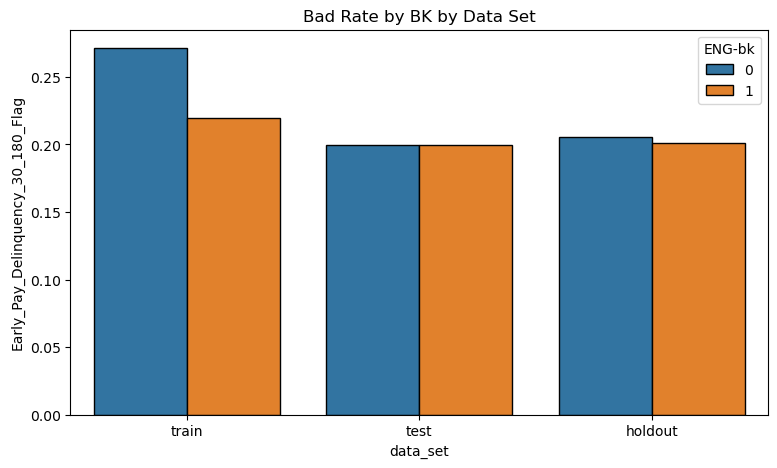

In [25]:
df_tmp = df.groupby(by=['data_set','ENG-bk'], as_index=False).agg({
    str_target: 'mean',
})
# sort
df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
df_tmp.sort_values(by=['sort','ENG-bk'], ascending=[True, True], inplace=True)
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by BK by Data Set')
sns.barplot(data=df_tmp, x='data_set', y=str_target, hue='ENG-bk', ax=ax, dodge=True, edgecolor='black')
# show
plt.show()

#### Bad rate by franchise by data set

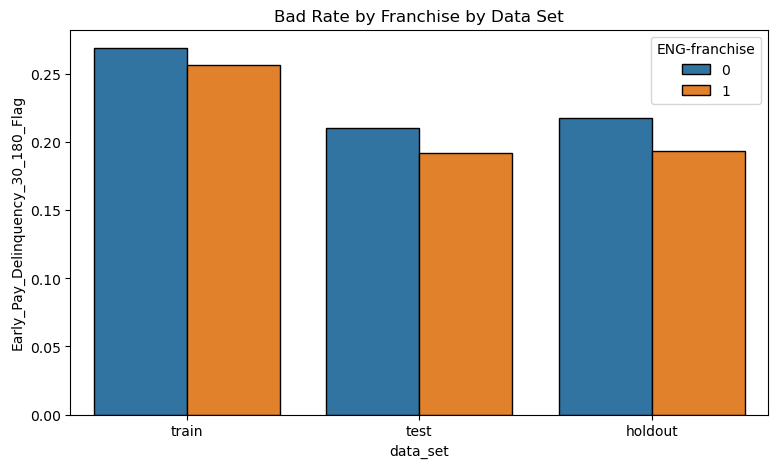

In [26]:
df_tmp = df.groupby(by=['data_set','ENG-franchise'], as_index=False).agg({
    str_target: 'mean',
})
# sort
df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
df_tmp.sort_values(by=['sort','ENG-franchise'], ascending=[True, True], inplace=True)
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by Franchise by Data Set')
sns.barplot(data=df_tmp, x='data_set', y=str_target, hue='ENG-franchise', ax=ax, dodge=True, edgecolor='black')
# show
plt.show()

#### Create tags

In [27]:
%%time

list_str_df = [
    'train',
    'test',
    'holdout',
]
for str_df in tqdm(list_str_df):
    df[str_df] = df['data_set'].apply(
        lambda x: 1 if x == str_df else 0,
    )
# show
df

100%|██████████| 3/3 [00:00<00:00, 36.48it/s]

CPU times: user 79 ms, sys: 7.44 ms, total: 86.4 ms
Wall time: 85.9 ms


,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_30_180_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,ENG-has_codebtor,...,inquirynonshortterm12month__ln,request_month,request_date,dtm_request_date,row,prop_row,data_set,train,test,holdout
0,2021-07-26 16:29:29.3903686,1285,2021-07-07 16:08:00.980,5702434,1,0,1.311220,1,1,0,...,1.0,2021-07-01,2021-07-26,2021-07-26,1,0.000012,train,1,0,0
1,2021-07-26 16:39:34.1121025,1285,2021-07-20 17:06:35.517,5714239,1,1,1.432368,0,1,0,...,0.0,2021-07-01,2021-07-26,2021-07-26,2,0.000024,train,1,0,0
2,2021-07-26 16:48:39.3211104,1285,2021-07-19 14:48:11.657,5713063,1,0,1.587073,1,1,0,...,1.0,2021-07-01,2021-07-26,2021-07-26,3,0.000036,train,1,0,0
3,2021-07-27 09:02:35.3300974,1284,2021-07-20 11:49:49.530,5713732,1,1,1.081881,0,0,0,...,1.0,2021-07-01,2021-07-27,2021-07-27,4,0.000048,train,1,0,0
4,2021-07-27 09:18:12.2190097,1283,2021-07-22 12:09:23.590,5715634,1,0,1.371350,0,1,0,...,0.0,2021-07-01,2021-07-27,2021-07-27,5,0.000060,train,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84022,2024-05-28 23:24:32+00:00,248,2024-05-25 11:49:50.837,7887989,1,0,1.297927,0,0,0,...,1.0,2024-05-01,2024-05-28,2024-05-28,84023,0.999952,holdout,0,0,1
84023,2024-05-28 23:47:34+00:00,248,2024-05-25 15:17:34.463,7889090,1,0,1.302958,0,1,0,...,1.0,2024-05-01,2024-05-28,2024-05-28,84024,0.999964,holdout,0,0,1
84024,2024-05-28 23:48:18+00:00,248,2024-05-17 13:37:19.497,7868893,1,0,1.126715,0,1,1,...,0.0,2024-05-01,2024-05-28,2024-05-28,84025,0.999976,holdout,0,0,1
84025,2024-05-28 23:48:18+00:00,248,2024-05-17 13:37:19.497,7868893,0,0,1.126715,0,1,1,...,1.0,2024-05-01,2024-05-28,2024-05-28,84026,0.999988,holdout,0,0,1


#### Make table into a png image

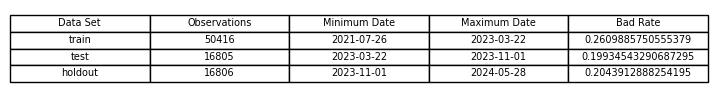

In [28]:
df['rows'] = 1
df['min_date'] = df['request_date']
df['max_date'] = df['request_date']
df_grouped = df.groupby(by='data_set', as_index=False).agg({
    'rows': 'count',
    'min_date': 'min',
    'max_date': 'max',
    str_target: 'mean',
})
# sort
df_grouped['sort'] = df_grouped['data_set'].map(dict_sort)
df_grouped.sort_values(by='sort', ascending=True, inplace=True)
df_grouped.drop('sort', axis=1, inplace=True)
# rename
dict_rename = {
    'data_set': 'Data Set',
    'rows': 'Observations',
    'min_date': 'Minimum Date',
    'max_date': 'Maximum Date',
    str_target: 'Bad Rate',
}
df_grouped.rename(columns=dict_rename, inplace=True)

# save
str_filename = 'df_info.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_grouped.to_csv(str_local_path, index=False)

# make into png
fig, ax = plt.subplots(figsize=(9,1))
ax.axis('tight')
ax.axis('off')
ax.table(cellText=df_grouped.values, colLabels=df_grouped.columns, cellLoc='center', loc='center')

# save
str_filename = 'plt_info.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Target mean by data set

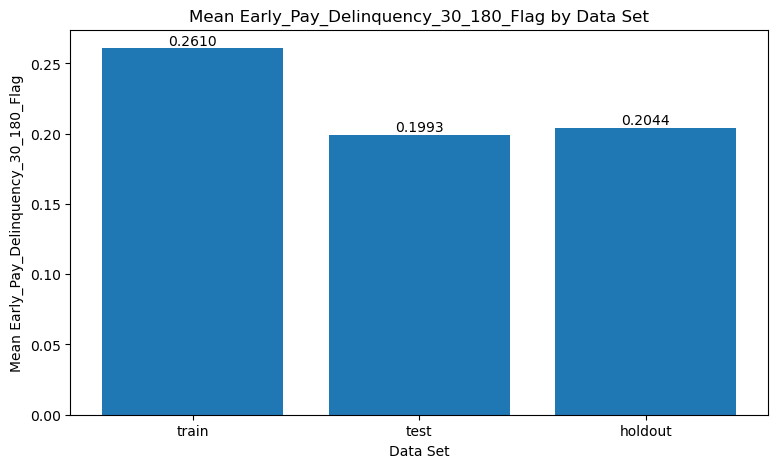

In [29]:
target_by_data_set(
    df=df,
    str_target=str_target,
)

#### Target mean by BK

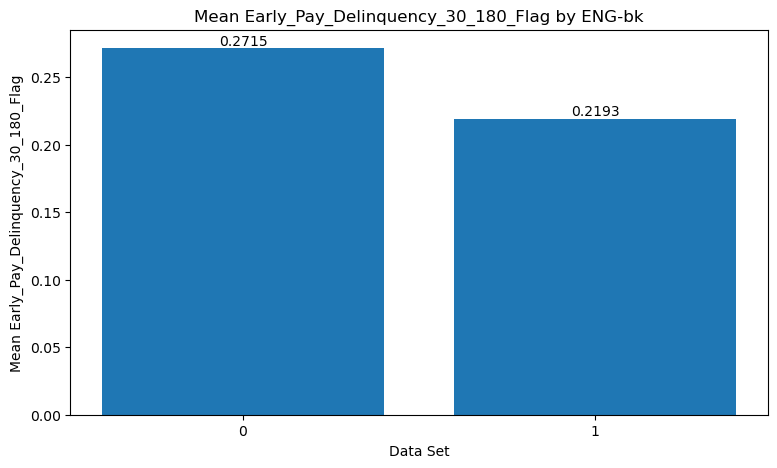

In [30]:
str_col = 'ENG-bk'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by dealer type

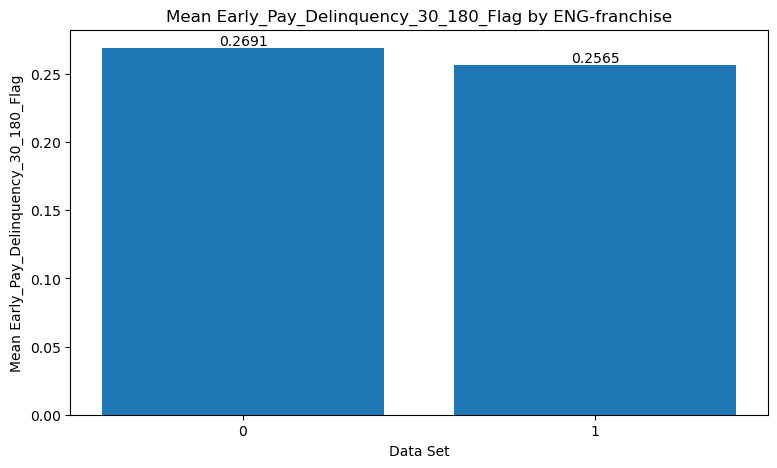

In [31]:
str_col = 'ENG-franchise'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Get relationship with target in training data

In [32]:
# import
str_filename = 'dict_monotone_constraints.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_monotone_constraints = pickle.load(open(str_local_path, 'rb'))

#### Create dictionary for imputation

In [33]:
# import
str_filename = 'dict_impute.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        # replace any infs with nan
        df[key] = df[key].replace(np.inf, np.nan)
        # fillna
        df[key] = df[key].fillna(val)
    except KeyError:
        pass
# show
df

100%|██████████| 1123/1123 [00:00<00:00, 12001.74it/s]


,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_30_180_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,ENG-has_codebtor,...,dtm_request_date,row,prop_row,data_set,train,test,holdout,rows,min_date,max_date
0,2021-07-26 16:29:29.3903686,1285,2021-07-07 16:08:00.980,5702434,1,0,1.311220,1,1,0,...,2021-07-26,1,0.000012,train,1,0,0,1,2021-07-26,2021-07-26
1,2021-07-26 16:39:34.1121025,1285,2021-07-20 17:06:35.517,5714239,1,1,1.432368,0,1,0,...,2021-07-26,2,0.000024,train,1,0,0,1,2021-07-26,2021-07-26
2,2021-07-26 16:48:39.3211104,1285,2021-07-19 14:48:11.657,5713063,1,0,1.587073,1,1,0,...,2021-07-26,3,0.000036,train,1,0,0,1,2021-07-26,2021-07-26
3,2021-07-27 09:02:35.3300974,1284,2021-07-20 11:49:49.530,5713732,1,1,1.081881,0,0,0,...,2021-07-27,4,0.000048,train,1,0,0,1,2021-07-27,2021-07-27
4,2021-07-27 09:18:12.2190097,1283,2021-07-22 12:09:23.590,5715634,1,0,1.371350,0,1,0,...,2021-07-27,5,0.000060,train,1,0,0,1,2021-07-27,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84022,2024-05-28 23:24:32+00:00,248,2024-05-25 11:49:50.837,7887989,1,0,1.297927,0,0,0,...,2024-05-28,84023,0.999952,holdout,0,0,1,1,2024-05-28,2024-05-28
84023,2024-05-28 23:47:34+00:00,248,2024-05-25 15:17:34.463,7889090,1,0,1.302958,0,1,0,...,2024-05-28,84024,0.999964,holdout,0,0,1,1,2024-05-28,2024-05-28
84024,2024-05-28 23:48:18+00:00,248,2024-05-17 13:37:19.497,7868893,1,0,1.126715,0,1,1,...,2024-05-28,84025,0.999976,holdout,0,0,1,1,2024-05-28,2024-05-28
84025,2024-05-28 23:48:18+00:00,248,2024-05-17 13:37:19.497,7868893,0,0,1.126715,0,1,1,...,2024-05-28,84026,0.999988,holdout,0,0,1,1,2024-05-28,2024-05-28


#### Bin features

In [34]:
df_train = df[df['data_set'] == 'train'].copy()
df_test = df[df['data_set'] == 'test'].copy()
df_holdout = df[df['data_set'] == 'holdout'].copy()
# save memory
del df

In [35]:
dict_bins, list_cols_scorecard, df_train, df_test, df_holdout = bin_features(
    list_cols=list_cols_model,
    X_train=df_train,
    y_train=df_train[str_target],
    X_test=df_test,
    X_holdout=df_holdout,
    dict_monotone_constraints=dict_monotone_constraints,
)
# pickle dict_bins
str_filename = 'dict_bins.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_bins, open(str_local_path, 'wb'))

100%|██████████| 42/42 [00:02<00:00, 19.57it/s]


#### Check for no variance bins

In [36]:
# make sure every column has at least 2 bins
list_col_no_var = []
for col in tqdm(list_cols_scorecard):
    int_n_unique = df_train[col].nunique()
    # logic
    if int_n_unique < 2:
        list_col_no_var.append(col)
    else:
        pass
print(f'There are {len(list_col_no_var)} features with no variance after binning')
# rm
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_col_no_var]
print(f'There are {len(list_cols_scorecard)} features available for scorecard inclusion')

100%|██████████| 42/42 [00:00<00:00, 1714.89it/s]

There are 0 features with no variance after binning
There are 42 features available for scorecard inclusion


In [37]:
list_col_no_var

[]

In [38]:
# show bins
df_tmp = df_train.copy()
df_tmp['target'] = df_train[str_target]
list_df = []
for col in tqdm(list_cols_scorecard):
    # get original column
    str_col_original = col.split('_binned')[0]
    # get min max and mean
    df_grouped = df_tmp.groupby(by=col, as_index=False).agg({
        str_col_original: ['min', 'max', 'count'],
        'target': 'mean',
    })
    # sort
    df_grouped.sort_values(by=(str_col_original, 'min'), ascending=True, inplace=True)
    df_grouped['feature'] = col
    # rename
    list_cols = ['bin','min','max','count','target','feature']
    df_grouped.columns = list_cols
    df_grouped['prop'] = df_grouped['count'] / df_grouped['count'].sum()
    # bin label
    df_grouped['bin_label'] = range(1, df_grouped.shape[0]+1)
    # reorder
    list_cols = ['feature','bin','min','max','count','prop','target','bin_label']
    df_grouped = df_grouped[list_cols].copy()
    # append
    list_df.append(df_grouped)
    
    #print(f'{a+1} - {str_col_original}')
    #print(df_grouped)
    #print()

# make df
df_bins = pd.concat(list_df)

# save
str_filename = 'df_bins.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_bins.to_csv(str_local_path, index=False)

# show
df_bins

100%|██████████| 42/42 [00:00<00:00, 139.63it/s]


,feature,bin,min,max,count,prop,target,bin_label
0,fltgrossmonthly__income_sum_binned,-0.028644,0.00,3854.64,24213,0.480264,0.266551,1
1,fltgrossmonthly__income_sum_binned,-0.017108,3854.69,4524.51,8006,0.158799,0.264302,2
2,fltgrossmonthly__income_sum_binned,0.013665,4524.53,5213.15,6189,0.122759,0.258362,3
3,fltgrossmonthly__income_sum_binned,0.063558,5213.35,11742.16,12008,0.238178,0.248917,4
5,miles_odometer__app_binned,0.105416,0.00,8185.00,2521,0.050004,0.241174,1
...,...,...,...,...,...,...,...,...
0,s209a__tu_binned,-0.016202,0.00,26.00,43786,0.868494,0.264126,1
1,s209a__tu_binned,0.094326,27.00,44.00,4013,0.079598,0.243210,2
2,s209a__tu_binned,0.135197,45.00,83.00,2617,0.051908,0.235766,3
1,inquirynonshortterm12month__ln_binned,0.263904,0.00,0.00,18297,0.362921,0.213368,1


In [39]:
df_bins[df_bins['feature'] == 'ENG-loan_to_value_binned']

,feature,bin,min,max,count,prop,target,bin_label
6,ENG-loan_to_value_binned,2.050206,0.185462,0.656261,69,0.001369,0.043478,1
5,ENG-loan_to_value_binned,0.870882,0.658687,0.775976,132,0.002618,0.128788,2
4,ENG-loan_to_value_binned,0.401547,0.776875,0.894086,340,0.006744,0.191176,3
3,ENG-loan_to_value_binned,0.271460,0.894686,1.012695,1636,0.032450,0.212103,4
2,ENG-loan_to_value_binned,0.094169,1.012792,1.130929,5657,0.112206,0.243238,5
1,ENG-loan_to_value_binned,-0.028571,1.130961,2.148742,42572,0.844414,0.266537,6
0,ENG-loan_to_value_binned,-0.193539,2.351604,2.549193,10,0.000198,0.300000,7


In [40]:
df_bins[df_bins['feature'] == 'fltgrossmonthly__income_sum_binned']

,feature,bin,min,max,count,prop,target,bin_label
0,fltgrossmonthly__income_sum_binned,-0.028644,0.00,3854.64,24213,0.480264,0.266551,1
1,fltgrossmonthly__income_sum_binned,-0.017108,3854.69,4524.51,8006,0.158799,0.264302,2
2,fltgrossmonthly__income_sum_binned,0.013665,4524.53,5213.15,6189,0.122759,0.258362,3
3,fltgrossmonthly__income_sum_binned,0.063558,5213.35,11742.16,12008,0.238178,0.248917,4


#### List of columns to start

In [41]:
# get number of features
int_n_feats_final_scorecard = len(list_cols_scorecard)
print(f'There are {int_n_feats_final_scorecard} features in the scorecard')

There are 42 features in the scorecard


#### Sampling

In [42]:
# get target value
flt_buffer = 0.035
flt_target_value = df_test[str_target].mean() + flt_buffer
print(f'Target Value: {flt_target_value:0.4f}')

Target Value: 0.2343


#### Get train to match

In [43]:
%%time

# get current target mean
flt_current_value = df_train[str_target].mean()
print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# init
cls_sample = OverSampling(
    df=df_train,
    str_target=str_target,
    flt_target_value=flt_target_value,
    flt_current_value=flt_current_value,
)
# sample
df_train = cls_sample.sample()
# get current target mean
flt_current_value = df_train[str_target].mean()
print(f'Target Value After Sampling: {flt_current_value:0.4f}')
print()
# show
df_train

Target Value Before Sampling: 0.2610
Target Value After Sampling: 0.2343

CPU times: user 99.1 ms, sys: 44.5 ms, total: 144 ms
Wall time: 167 ms


,request_datetime,days_on_books,applicationdate__app,accountid,bitdebtor__app,Early_Pay_Delinquency_30_180_Flag,ENG-loan_to_value,ENG-bk,ENG-franchise,ENG-has_codebtor,...,fi36s__tu_binned,linkf098__tu_binned,linka006__tu_binned,fi25s__tu_binned,addrinputsubjectcount__ln_binned,g251c__tu_binned,inquiryshortterm12month__ln_binned,g095s__tu_binned,s209a__tu_binned,inquirynonshortterm12month__ln_binned
21036,2022-05-24 22:59:35+00:00,983,2022-05-03 10:51:43.063,6050979,0,0,1.367039,0,0,1,...,0.262061,-0.002276,-0.147935,-0.036670,0.098640,0.234570,0.098834,-0.072506,-0.016202,0.263904
9716,2022-01-11 01:00:15+00:00,1117,2022-01-07 10:20:58.233,5889093,1,0,1.277958,0,0,0,...,-0.088180,-0.002276,0.347130,-0.036670,-0.080403,-0.079051,0.098834,-0.072506,-0.016202,0.263904
25979,2022-07-12 05:00:22+00:00,935,2022-07-02 10:50:41.303,6149447,0,0,1.586240,0,1,1,...,0.262061,-0.002276,-0.147935,-0.036670,-0.080403,0.234570,-0.336080,-0.072506,-0.016202,-0.136285
25840,2022-07-09 03:58:14+00:00,938,2022-06-29 12:07:12.237,6144474,0,0,1.494528,0,1,1,...,-0.088180,-0.002276,-0.147935,-0.036670,-0.080403,-0.079051,-0.336080,-0.072506,-0.016202,0.263904
45448,2023-01-24 05:51:58+00:00,739,2023-01-16 08:07:10.330,6550188,0,0,1.317551,0,0,1,...,-0.088180,-0.002276,0.109589,0.173704,0.098640,-0.079051,0.098834,-0.072506,-0.016202,-0.136285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25667,2022-07-07 23:43:31+00:00,939,2022-07-02 07:49:24.763,6148896,1,1,1.029727,0,1,0,...,-0.088180,-0.002276,-0.147935,-0.036670,0.098640,-0.004210,0.098834,-0.072506,-0.016202,0.263904
47862,2023-02-24 03:42:48+00:00,708,2023-02-15 18:08:52.617,6613107,1,0,0.945742,0,1,0,...,0.262061,-0.002276,0.004886,-0.036670,0.098640,0.078094,0.098834,0.162333,-0.016202,0.263904
3891,2021-10-16 11:13:43+00:00,1204,2021-10-01 15:03:29.363,5781519,0,1,1.518640,0,0,1,...,-0.088180,-0.002276,0.123792,-0.036670,0.098640,-0.004210,0.098834,-0.072506,-0.016202,-0.136285
1076,2021-08-30 19:35:58.0125730,1250,2021-08-16 11:34:29.567,5737770,1,0,1.240569,1,1,0,...,-0.088180,-0.002276,-0.147935,-0.036670,0.041544,-0.079051,0.098834,0.162333,0.135197,0.263904


#### Split into X and y

In [44]:
# train
X_train = df_train[[col for col in list_cols_scorecard if col != str_target]].copy()
y_train = df_train[str_target]
# save memory
del df_train

In [45]:
# test
X_test = df_test[[col for col in list_cols_scorecard if col != str_target]].copy()
y_test = df_test[str_target]
# save memory
del df_test

In [46]:
# holdout
X_holdout = df_holdout[[col for col in list_cols_scorecard if col != str_target]].copy()
y_holdout = df_holdout[str_target]
# assign
X_holdout['ENG-bk'] = df_holdout['ENG-bk']
X_holdout['ENG-franchise'] = df_holdout['ENG-franchise']
# save memory
del df_holdout

#### Scorecard

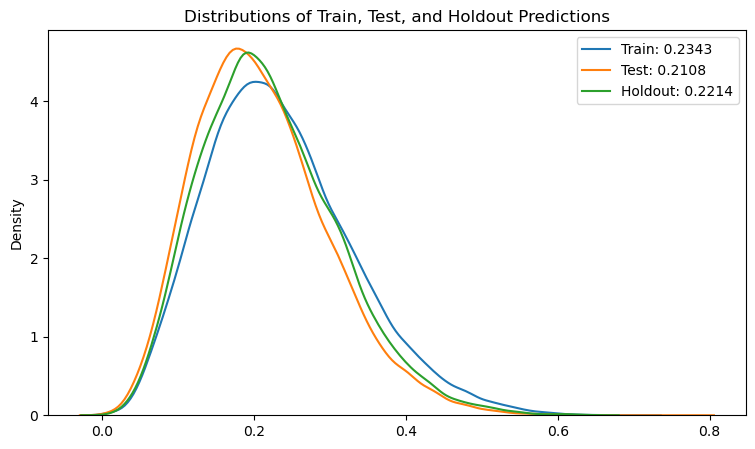

In [47]:
# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
#     penalty='l1',
#     solver='liblinear',
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [48]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6529
AUC Test: 0.6222
AUC Holdout: 0.6143

Logloss Train: 0.5179
Logloss Test: 0.4851
Logloss Holdout: 0.4951

KS Train: 0.2209
KS Test: 0.1742
KS Holdout: 0.1728


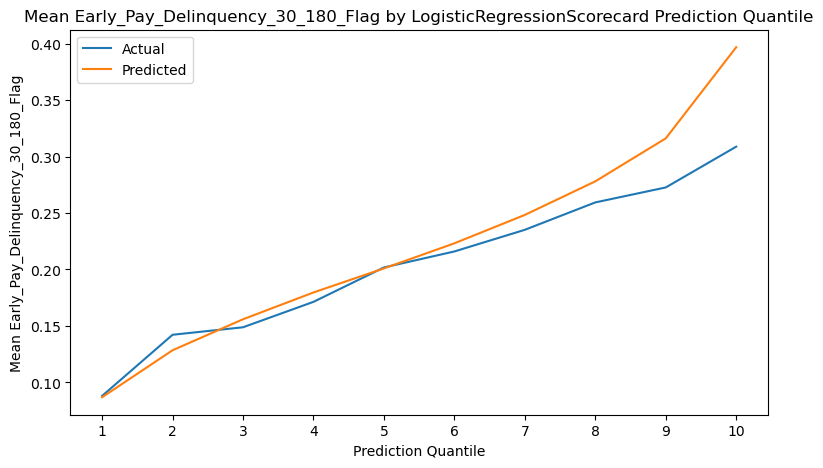

In [49]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

#### Sensitivity tuning/analysis

In [50]:
# list_cols_scorecard_new = list_cols_scorecard.copy()
# flt_score_high = flt_auc_test
# list_dict_row_outer = []
# while True:
#     list_dict_row = []
#     for col_a in tqdm(list_cols_scorecard_new):
#         # rm col
#         list_cols_scorecard_tmp = [col_b for col_b in list_cols_scorecard_new if col_b != col_a]

#         # init
#         cls_model_inference = LogisticRegression(
#             random_state=42,
#             fit_intercept=True,
# #             penalty='l1',
# #             solver='liblinear',
#         )
#         # fit
#         cls_model_inference.fit(
#             X_train[list_cols_scorecard_tmp].copy(),
#             y_train,
#         )
#         # adjust weights
#         cls_model_inference = weight_the_coefficients(
#             cls_model_inference=cls_model_inference,
#             dict_weights=dict_weights,
#         )

#         # get predictions
#         list_predictions_tmp = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard_tmp])[:,1])
#         # prep for partial score
#         df_pred = prep_for_partial_score(
#             list_predictions=list_predictions_tmp,
#             y_actual=y_test,
#             flt_prop_pred=flt_prop_pred,
#         )
#         # get auc
#         flt_score = skm.roc_auc_score(
#             y_true=df_pred['actual'],
#             y_score=df_pred['pred'],
#         )
#         # make row
#         dict_row = {
#             'feature': col_a,
#             'score': flt_score,
#             'target': flt_score_high,
#         }
#         # append
#         list_dict_row.append(dict_row)
#     # make df
#     df_tmp = pd.DataFrame(list_dict_row)
#     # get diff
#     df_tmp['diff'] = df_tmp['score'] - df_tmp['target']
#     # get the features that help when removed
#     df_tmp = df_tmp[df_tmp['diff'] >= 0].copy()
    
#     # logic
#     if df_tmp.shape[0] == 0:
#         break
#     else:
#         pass
    
#     # find the feature that helps the most
#     df_tmp.sort_values(by='diff', ascending=False, inplace=True)
#     str_col_help = df_tmp['feature'].iloc[0]
#     flt_score_high = df_tmp['score'].iloc[0]
    
#     # make row
#     dict_row_outer = {
#         'feature': str_col_help,
#         'score': flt_score_high,
#     }
#     # append
#     list_dict_row_outer.append(dict_row_outer)
    
#     # rm
#     list_cols_scorecard_new = [col for col in list_cols_scorecard_new if col != str_col_help]

# # make df
# df_sensitivity = pd.DataFrame(list_dict_row_outer)

# # save
# str_filename = 'df_sensitivity.csv'
# str_local_path = f'{str_dirname_output}/{str_filename}'
# df_sensitivity.to_csv(str_local_path, index=False)

# # show
# df_sensitivity

In [51]:
# # plot
# x = df_sensitivity['feature']
# y = df_sensitivity['score']
# fig, ax = plt.subplots(figsize=(12,5))
# ax.set_title('AUC by Feature Removed')
# ax.set_ylabel('AUC')
# ax.plot(x, y)
# ax.set_xticklabels(x, rotation=90)
# plt.show()

In [52]:
# # cols to remove
# list_cols_rm = list(df_sensitivity['feature'])
# print(f'There are {len(list_cols_rm)} features to remove')
# list_cols_rm

In [53]:
# rm
#list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_cols_rm]
# get number of features
int_n_feats_final_scorecard = len(list_cols_scorecard)
print(f'There are {int_n_feats_final_scorecard} features in the scorecard')
# rows for scorecard graph
int_nrows = math.ceil(int_n_feats_final_scorecard / int_ncols)

There are 42 features in the scorecard


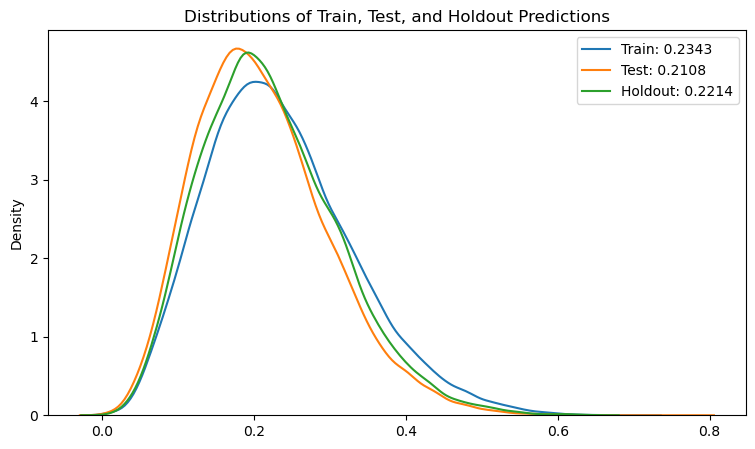

In [54]:
# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
#     penalty='l1',
#     solver='liblinear',
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# save
str_filename = f'{str_name_model}.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

# upload to s3
str_bucket_key = f'{str_task}/{str_subtask}/{str_filename}'
upload_to_s3(
    str_local_path=str_local_path,
    str_bucket_key=str_bucket_key,
    str_bucket_name=str_project,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

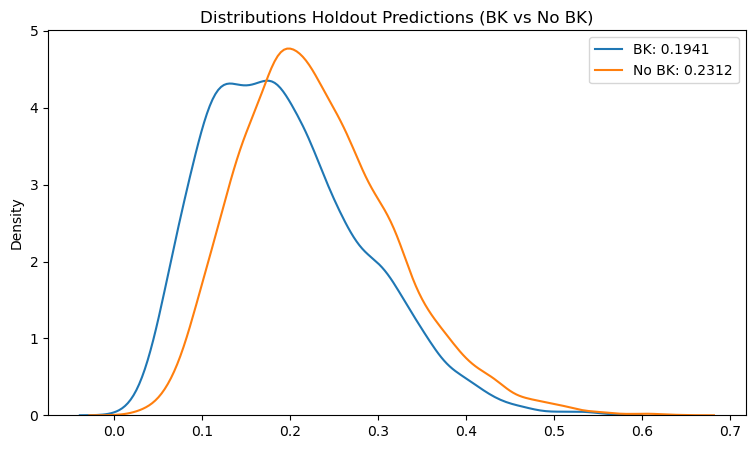

In [55]:
# holdout by bk non bk
df_tmp_bk = X_holdout.copy()
df_tmp_bk['yhat'] = list_predictions_holdout
list_predictions_bk = list(df_tmp_bk[df_tmp_bk['ENG-bk'] == 1]['yhat'])
list_predictions_nobk = list(df_tmp_bk[df_tmp_bk['ENG-bk'] == 0]['yhat'])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions Holdout Predictions (BK vs No BK)')
sns.kdeplot(list_predictions_bk, label=f'BK: {np.mean(list_predictions_bk):0.4f}')
sns.kdeplot(list_predictions_nobk, label=f'No BK: {np.mean(list_predictions_nobk):0.4f}')
# legend
ax.legend()
# show
plt.show()

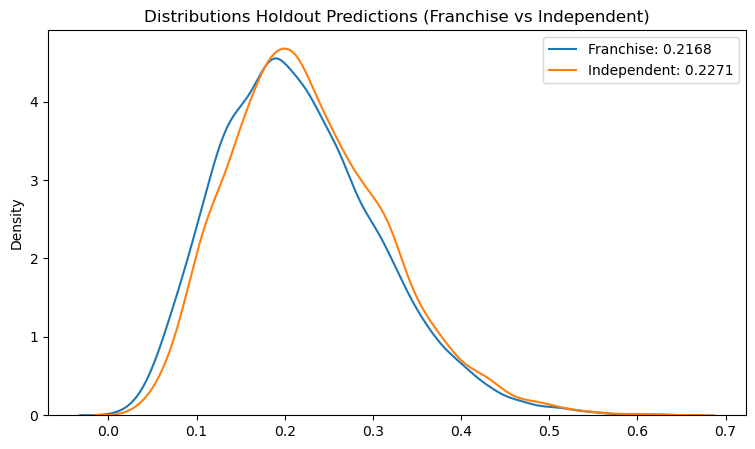

In [56]:
# holdout by franchise/ind
df_tmp_bk = X_holdout.copy()
df_tmp_bk['yhat'] = list_predictions_holdout
list_predictions_franchise = list(df_tmp_bk[df_tmp_bk['ENG-franchise'] == 1]['yhat'])
list_predictions_independent = list(df_tmp_bk[df_tmp_bk['ENG-franchise'] == 0]['yhat'])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions Holdout Predictions (Franchise vs Independent)')
sns.kdeplot(list_predictions_franchise, label=f'Franchise: {np.mean(list_predictions_franchise):0.4f}')
sns.kdeplot(list_predictions_independent, label=f'Independent: {np.mean(list_predictions_independent):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [57]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6529
AUC Test: 0.6222
AUC Holdout: 0.6143

Logloss Train: 0.5179
Logloss Test: 0.4851
Logloss Holdout: 0.4951

KS Train: 0.2209
KS Test: 0.1742
KS Holdout: 0.1728


#### Get intercept

In [58]:
# get intercept
flt_intercept = cls_model_inference.intercept_[0]
print(f'Intercept: {flt_intercept}')

Intercept: -1.1855380480589568


In [59]:
# get feature importance
dict_map_descriptions_bin = {f'{key}_binned': val for key, val in dict_map_descriptions.items()}
df_tmp = get_logistic_regression_feat_importance(
    cls_model_inference=cls_model_inference,
    list_cols_model=list_cols_scorecard,
    df=X_test,
)
# map desceription
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_feat_imp.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,importance,importance_abs,description
23,ENG-bk_binned,-3.341926e-02,3.341926e-02,NaN
3,rtl_trd__tu_binned,-2.505816e-02,2.505816e-02,Number of retail trades
39,g095s__tu_binned,-2.367260e-02,2.367260e-02,Months since most recent public record
26,trv01__tu_binned,-2.076399e-02,2.076399e-02,Number of months since overlimit on a bankcard
11,all235__tu_binned,-1.389202e-02,1.389202e-02,Aggregate Excess Payment for All accounts over...
6,balmag01__tu_binned,-1.167997e-02,1.167997e-02,Non-mortgage balance magnitude algorithm over ...
12,cv15__tu_binned,-1.088932e-02,1.088932e-02,Number of deduped auto inquiries
5,rev322__tu_binned,-1.079912e-02,1.079912e-02,Min Total Open-to-Buy for Revolving accounts o...
13,derogseverityindex__ln_binned,-1.016482e-02,1.016482e-02,Index indicating severity of derogatory record...
37,g251c__tu_binned,9.692087e-03,9.692087e-03,Number of 60 days past due or worse items in t...


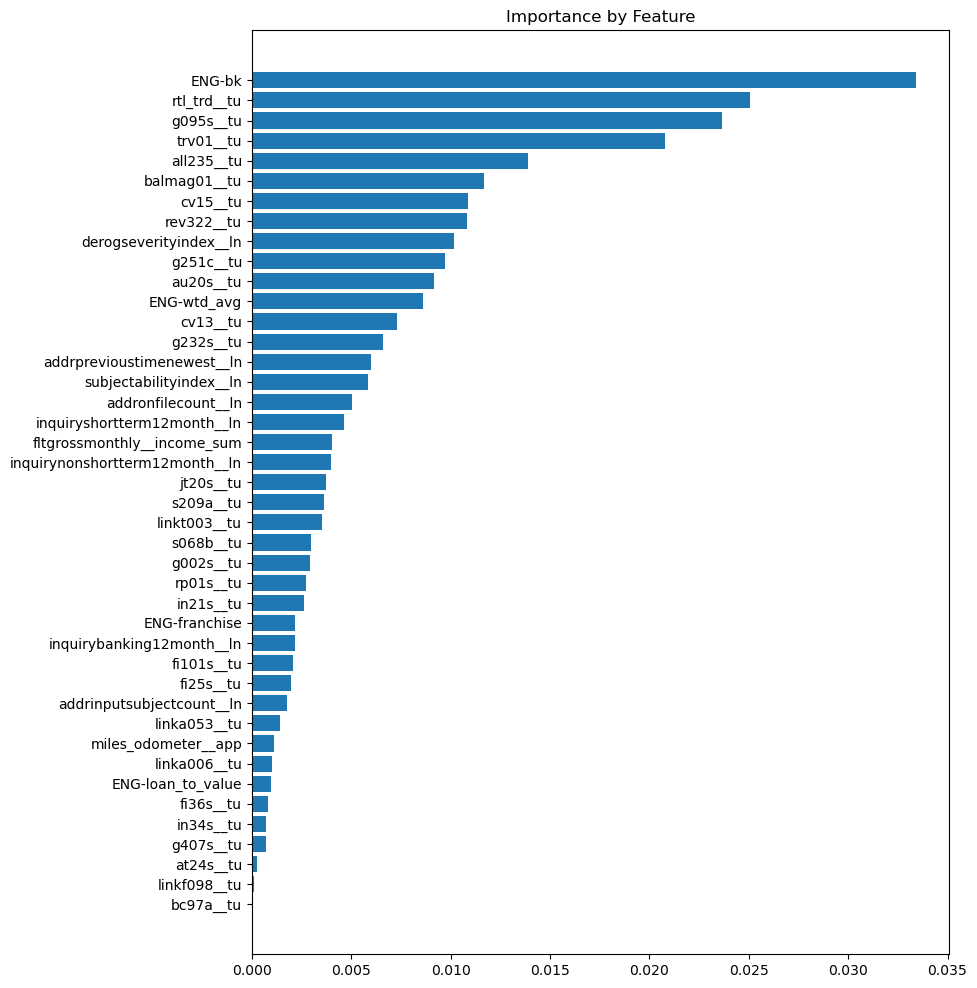

In [60]:
# plot
df_tmp.sort_values(by='importance_abs', ascending=True, inplace=True)
df_tmp['feature_tmp'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
x = df_tmp['feature_tmp']
y = df_tmp['importance_abs']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Importance by Feature')
ax.barh(x, y)

# save
str_filename = 'feat_importance.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

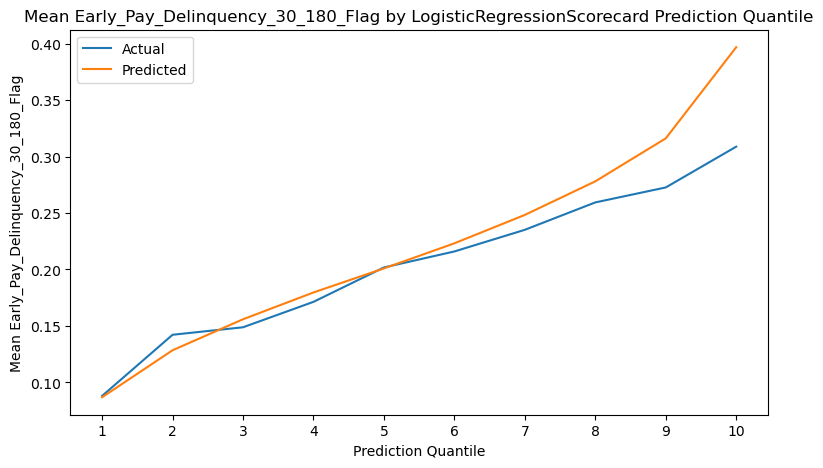

In [61]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

In [62]:
# # directions of predictions
# int_n_quantiles = 10
# get_directions_of_predictions_for_scorecard(
#     X=X_holdout.copy(),
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_scorecard,
#     df_bins=df_bins,
# )

#### Show scorecard

In [63]:
# copy df_bins
df_identity = df_bins[df_bins['feature'].isin(list_cols_scorecard)].copy()

df_coef = pd.DataFrame({
    'feature': cls_model_inference.feature_names_in_,
    'coef': cls_model_inference.coef_[0],
})
# create dictionary
dict_map_coef = dict(zip(df_coef['feature'], df_coef['coef']))

# map to df_identity
df_identity['coef'] = df_identity['feature'].map(dict_map_coef)

# multiply by bin value
df_identity['contribution'] = df_identity['bin'] * df_identity['coef']

# sort
df_identity.sort_values(by=['feature','contribution'], ascending=[True,True], inplace=True)

# get description
df_identity['description'] = df_identity['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_scorecard.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity.to_csv(str_local_path, index=False)

# show
df_identity

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
1,ENG-bk_binned,0.229105,1.000000,1.000000,10152,0.201365,0.219267,2,-0.727641,-0.166707,NaN
0,ENG-bk_binned,-0.053852,0.000000,0.000000,40264,0.798635,0.271508,1,-0.727641,0.039185,NaN
1,ENG-franchise_binned,0.023442,1.000000,1.000000,32383,0.642316,0.256493,2,-0.813853,-0.019078,NaN
0,ENG-franchise_binned,-0.041451,0.000000,0.000000,18033,0.357684,0.269062,1,-0.813853,0.033735,NaN
6,ENG-loan_to_value_binned,2.050206,0.185462,0.656261,69,0.001369,0.043478,1,-0.879919,-1.804015,NaN
...,...,...,...,...,...,...,...,...,...,...,...
0,subjectabilityindex__ln_binned,-0.096653,1.000000,1.000000,22142,0.439186,0.280056,1,-0.264391,0.025554,Modeled risk index indicating the subject's ab...
3,trv01__tu_binned,0.256001,20.000000,999.000000,10750,0.213226,0.214698,4,-0.561653,-0.143784,Number of months since overlimit on a bankcard
2,trv01__tu_binned,0.123250,5.000000,19.000000,2526,0.050103,0.237926,3,-0.561653,-0.069223,Number of months since overlimit on a bankcard
1,trv01__tu_binned,0.025644,2.000000,4.000000,2964,0.058791,0.256073,2,-0.561653,-0.014403,Number of months since overlimit on a bankcard


#### Graph it

100%|██████████| 42/42 [00:01<00:00, 27.68it/s]


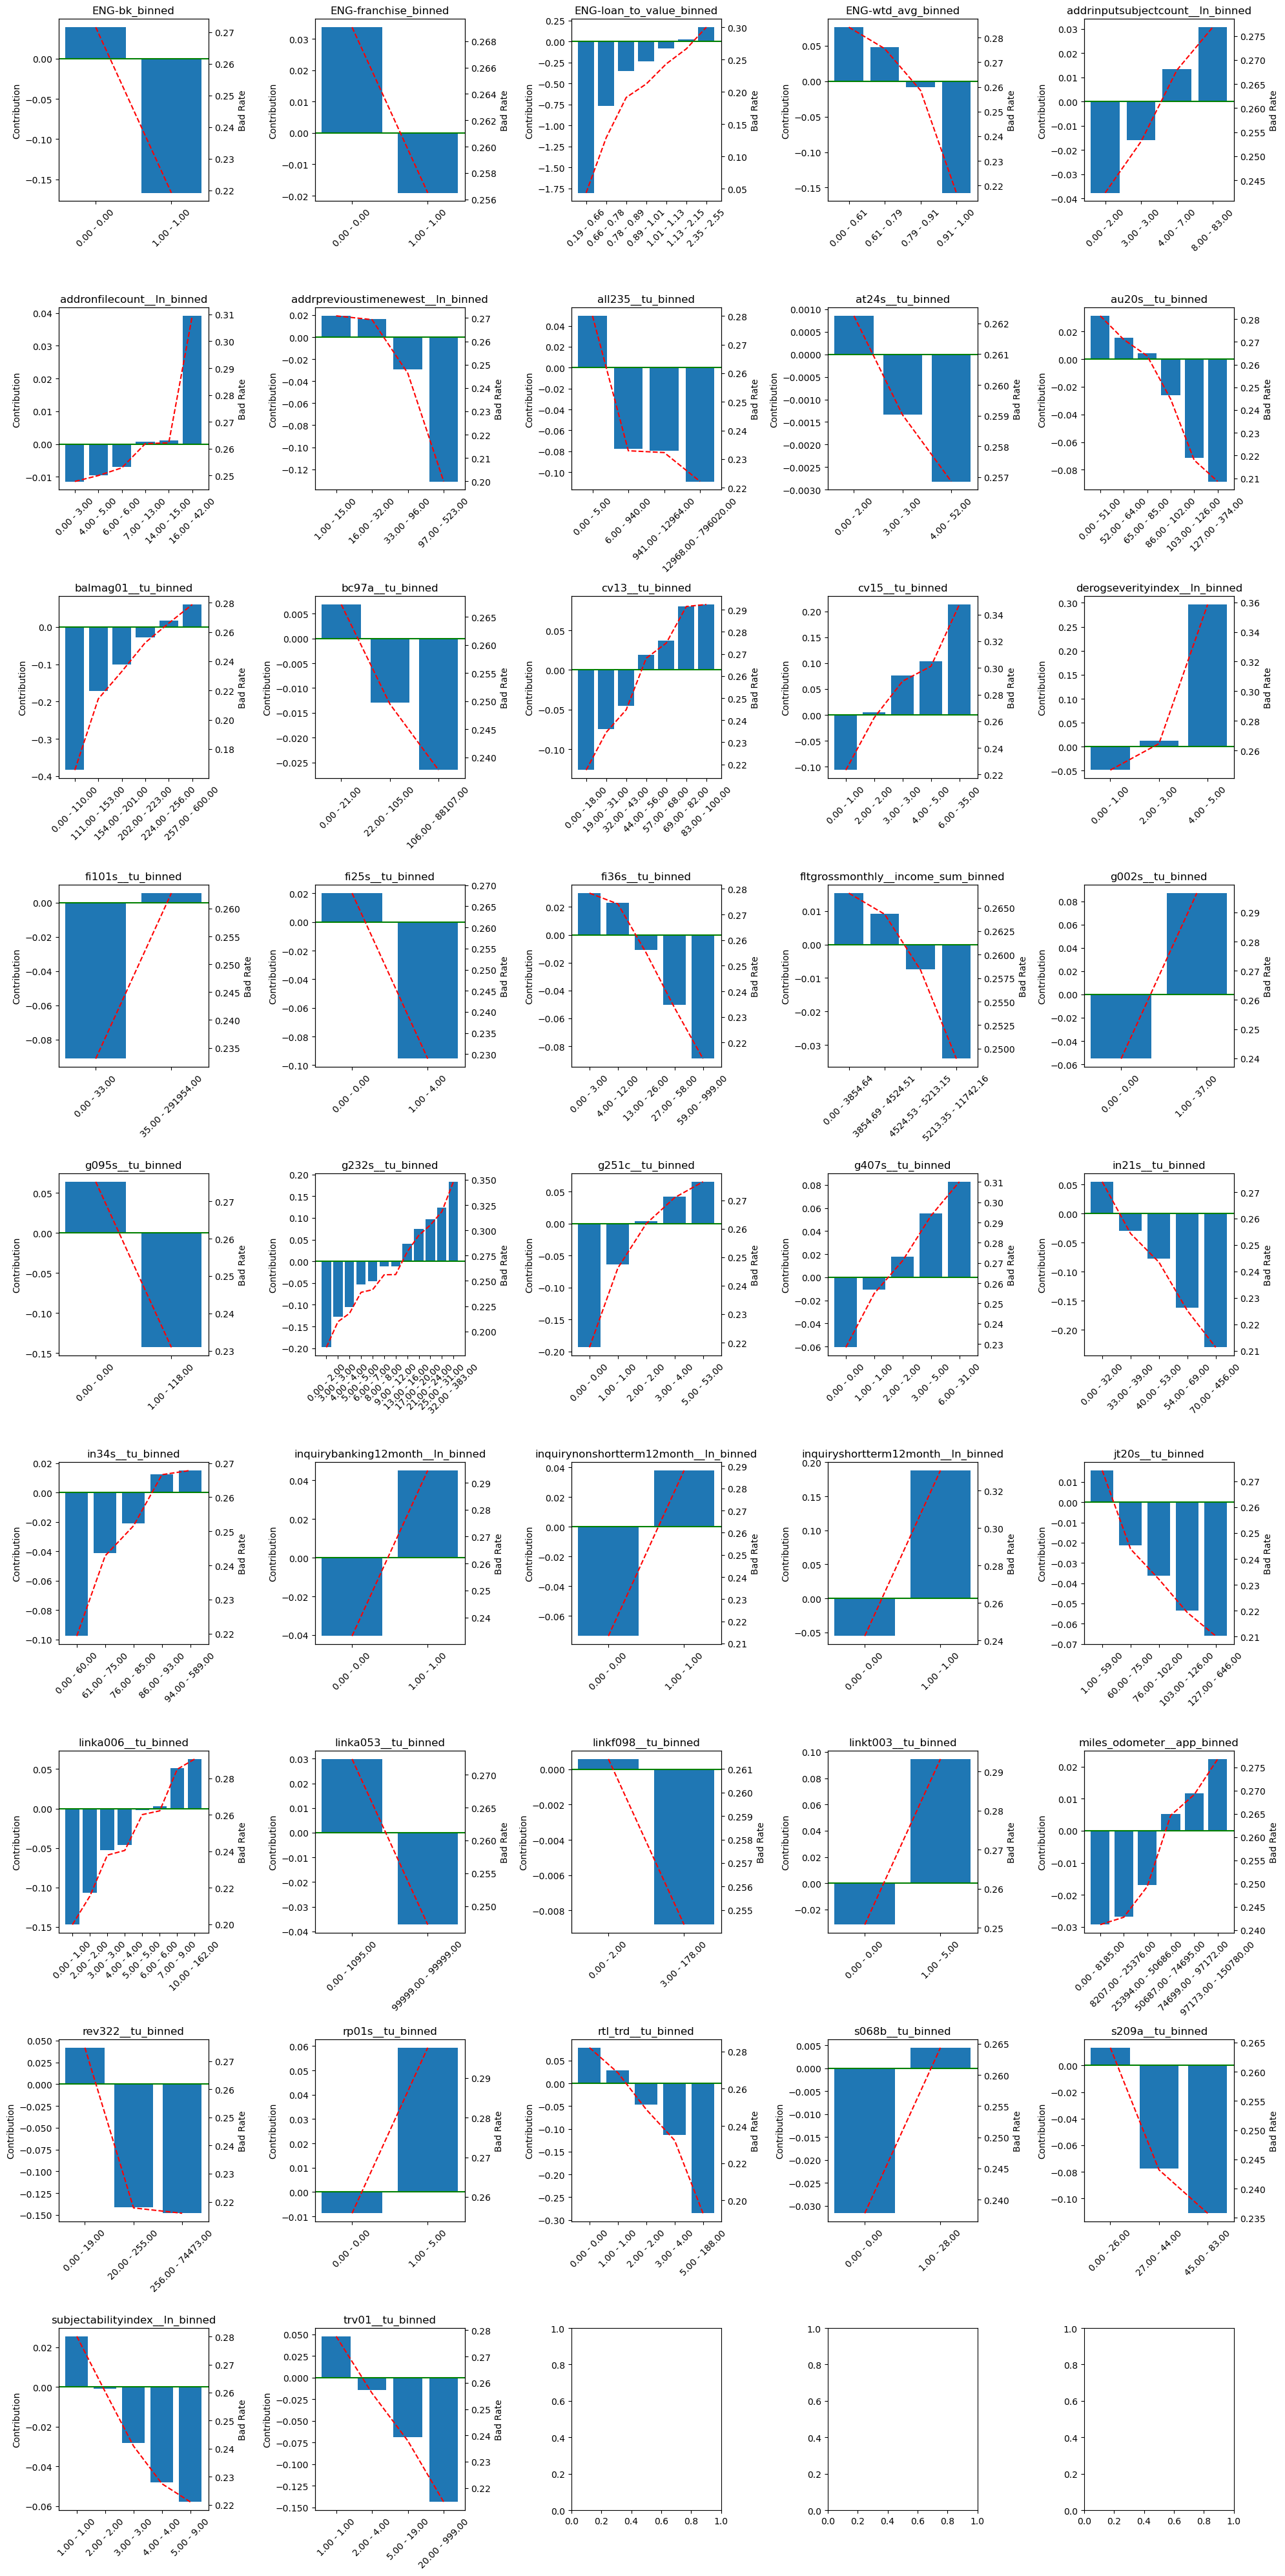

In [64]:
# get the unique values
list_feats_unique = list(df_identity['feature'].unique())

# plot
fig, ax = plt.subplots(nrows=int_nrows, ncols=int_ncols, figsize=(20, 40))

# iterate through features
counter = 0
int_row_start = 0
int_col_start = 0
for str_feat in tqdm(list_feats_unique):
    # logic for row, col
    if (int_col_start % int_ncols == 0) and (counter != 0):
        # add 1 to row
        int_row_start += 1
        # reset int_col_start
        int_col_start = 0
    else:
        pass
    
    # get row
    int_idx_row = int_row_start
    # get col
    int_idx_col = int_col_start
    # subset
    df_tmp = df_identity[df_identity['feature'] == str_feat].copy()
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create label
    df_tmp['label'] = df_tmp.apply(
        lambda x: f'{x["min"]:0.2f} - {x["max"]:0.2f}',
        axis=1,
    )
    # x and y
    x = df_tmp['label']
    y = df_tmp['contribution']
    z = df_tmp['target']
    # plot
    ax[int_idx_row, int_idx_col].set_title(str_feat)
    ax[int_idx_row, int_idx_col].set_ylabel('Contribution')
    ax[int_idx_row, int_idx_col].bar(x, y)
    ax[int_idx_row, int_idx_col].set_xticklabels(x, rotation=45)
    # horizontal line at 0
    ax[int_idx_row, int_idx_col].axhline(0, color='green')
    # second y
    ax2 = ax[int_idx_row, int_idx_col].twinx()
    ax2.set_ylabel('Bad Rate')
    ax2.plot(x, z, color='red', linestyle='--')
    # add
    counter += 1
    int_col_start += 1

# fix overlap
plt.tight_layout()

# save
str_filename = 'plt_scorecard.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Programmatically find flipped features

In [65]:
list_str_col = list(df_identity['feature'].unique())
list_cols_flip = []
for str_col in tqdm(list_str_col):
    # subset
    df_tmp = df_identity[df_identity['feature'] == str_col].copy()
    # sort by contribution lowest to highest
    df_tmp.sort_values(by='contribution', ascending=True, inplace=True)
    # get the first bad rate
    flt_bad_rate_first = df_tmp['target'].iloc[0]
    # get the last bad rate
    flt_bad_rate_last = df_tmp['target'].iloc[-1]
    # make sure the last bad rate is larger than the first
    flt_diff = flt_bad_rate_last - flt_bad_rate_first
    # if the difference is negative
    if flt_diff < 0:
        # the feature flipped
        list_cols_flip.append(str_col)
    else:
        pass

# print message
int_ncols = len(list_cols_flip)
print(f'There are {int_ncols} features that flipped, please manually review and remove:')
for col in list_cols_flip:
    col = col.split('_binned')[0]
    print(f"'{col}',")

100%|██████████| 42/42 [00:00<00:00, 830.25it/s]

There are 0 features that flipped, please manually review and remove:


#### Show identity

In [66]:
df_identity_sub = df_identity.drop_duplicates(subset=['feature'], keep='first', inplace=False)

# sort
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)

# save
str_filename = 'df_scorecard_sub.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity_sub.to_csv(str_local_path, index=False)

# show
df_identity_sub

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
6,ENG-loan_to_value_binned,2.050206,0.185462,0.656261,69,0.001369,0.043478,1,-0.879919,-1.804015,NaN
5,balmag01__tu_binned,0.575861,0.000000,110.000000,3314,0.065733,0.165661,1,-0.666704,-0.383929,Non-mortgage balance magnitude algorithm over ...
4,rtl_trd__tu_binned,0.389404,5.000000,188.000000,4900,0.097191,0.193061,5,-0.733148,-0.285491,Number of retail trades
4,in21s__tu_binned,0.276029,70.000000,456.000000,4850,0.096200,0.211340,5,-0.833249,-0.230001,Months since most recent installment trade opened
11,g232s__tu_binned,0.446838,0.000000,2.000000,3484,0.069105,0.184271,1,-0.443495,-0.198171,Number of inquiries (includes duplicates)
4,g251c__tu_binned,0.234570,0.000000,0.000000,6371,0.126369,0.218333,1,-0.826109,-0.193781,Number of 60 days past due or worse items in t...
1,ENG-bk_binned,0.229105,1.000000,1.000000,10152,0.201365,0.219267,2,-0.727641,-0.166707,NaN
3,ENG-wtd_avg_binned,0.242163,0.911373,1.000000,15845,0.314285,0.217040,4,-0.650297,-0.157478,NaN
2,rev322__tu_binned,0.248604,256.000000,74473.000000,5932,0.117661,0.215947,3,-0.595835,-0.148127,Min Total Open-to-Buy for Revolving accounts o...
7,linka006__tu_binned,0.347130,0.000000,1.000000,5983,0.118673,0.199733,1,-0.423482,-0.147003,Number of total inquiries in the last 3 years....


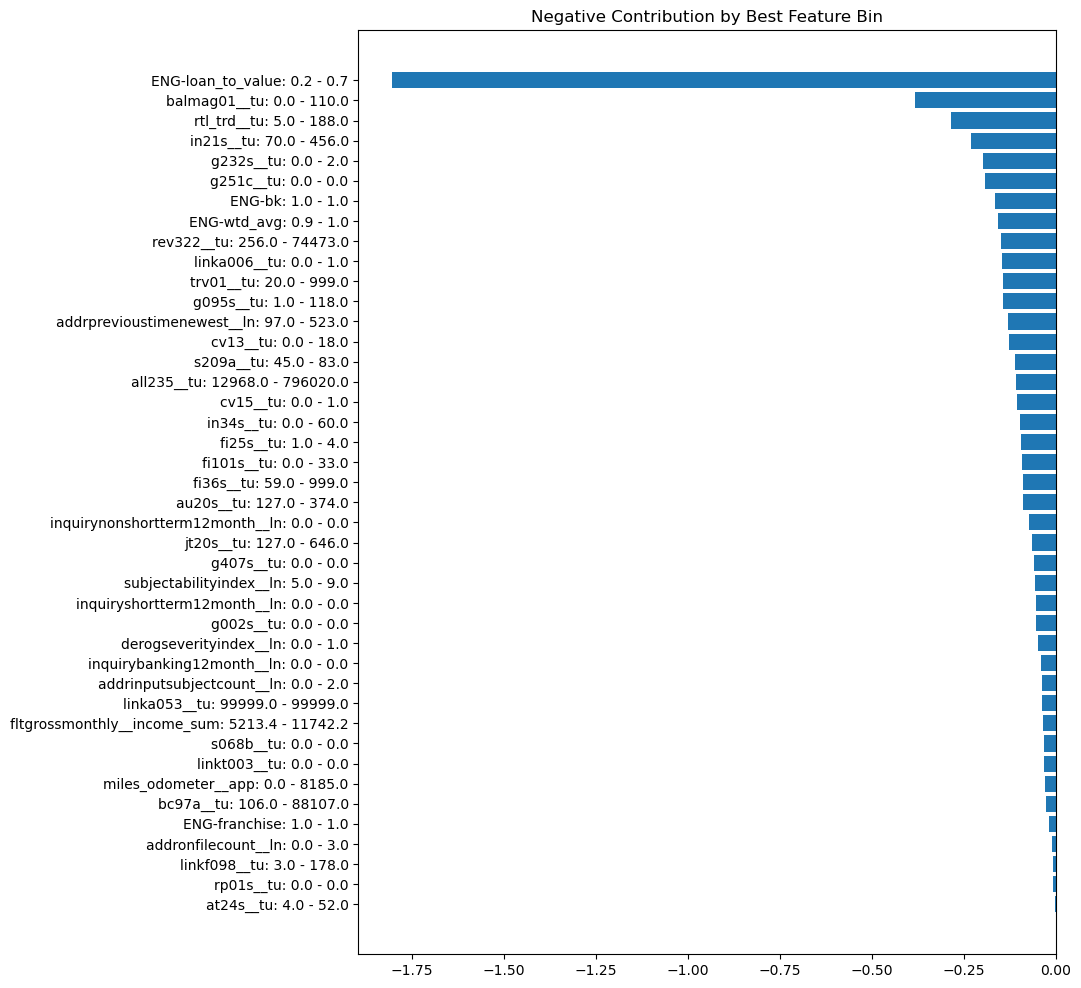

In [67]:
# plot
df_identity_sub['label'] = df_identity_sub.apply(
    lambda x: f"{x['feature'].split('_binned')[0]}: {x['min']:0.1f} - {x['max']:0.1f}",
    axis=1,
)

# plot
df_identity_sub.sort_values(by='contribution', ascending=False, inplace=True)
x = df_identity_sub['label']
y = df_identity_sub['contribution']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Negative Contribution by Best Feature Bin')
ax.barh(x, y)

# save
str_filename = 'best_bin.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Show what is not our identity

In [68]:
# sort
df_identity.sort_values(by=['feature','contribution'], ascending=[True,False], inplace=True)

df_identity_sub = df_identity.drop_duplicates(subset=['feature'], keep='first', inplace=False)

# sort
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)

# save
str_filename = 'df_scorecard_sub_anti.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity_sub.to_csv(str_local_path, index=False)

# show
df_identity_sub

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
0,linkf098__tu_binned,-0.002276,0.000000,2.000000,47275,0.937698,0.261428,1,-0.254645,0.000580,Number of satisfactory trades
0,at24s__tu_binned,-0.006521,0.000000,2.000000,37148,0.736830,0.262248,1,-0.130859,0.000853,Number of currently open and satisfactory trad...
0,s068b__tu_binned,-0.017522,1.000000,28.000000,43978,0.872302,0.264382,2,-0.255026,0.004469,Number of non-medical third party collections
0,fi101s__tu_binned,-0.009172,35.000000,291954.000000,47408,0.940336,0.262762,2,-0.606243,0.005561,Total balance of all finance installment trade...
0,bc97a__tu_binned,-0.032094,0.000000,21.000000,38619,0.766007,0.267226,1,-0.213212,0.006843,Total open to buy of open credit cards verifie...
0,s209a__tu_binned,-0.016202,0.000000,26.000000,43786,0.868494,0.264126,1,-0.821769,0.013314,Months since most recent non-medical third par...
0,in34s__tu_binned,-0.035295,94.000000,589.000000,35792,0.709933,0.267853,5,-0.426716,0.015061,Utilization for open installment trades verifi...
0,fltgrossmonthly__income_sum_binned,-0.028644,0.000000,3854.640000,24213,0.480264,0.266551,1,-0.537178,0.015387,NaN
0,jt20s__tu_binned,-0.067248,1.000000,59.000000,36467,0.723322,0.274166,1,-0.233866,0.015727,Months since oldest joint trade opened
0,addrprevioustimenewest__ln_binned,-0.050927,1.000000,15.000000,33887,0.672148,0.270930,1,-0.379110,0.019307,Time (in months) since the subject was most re...


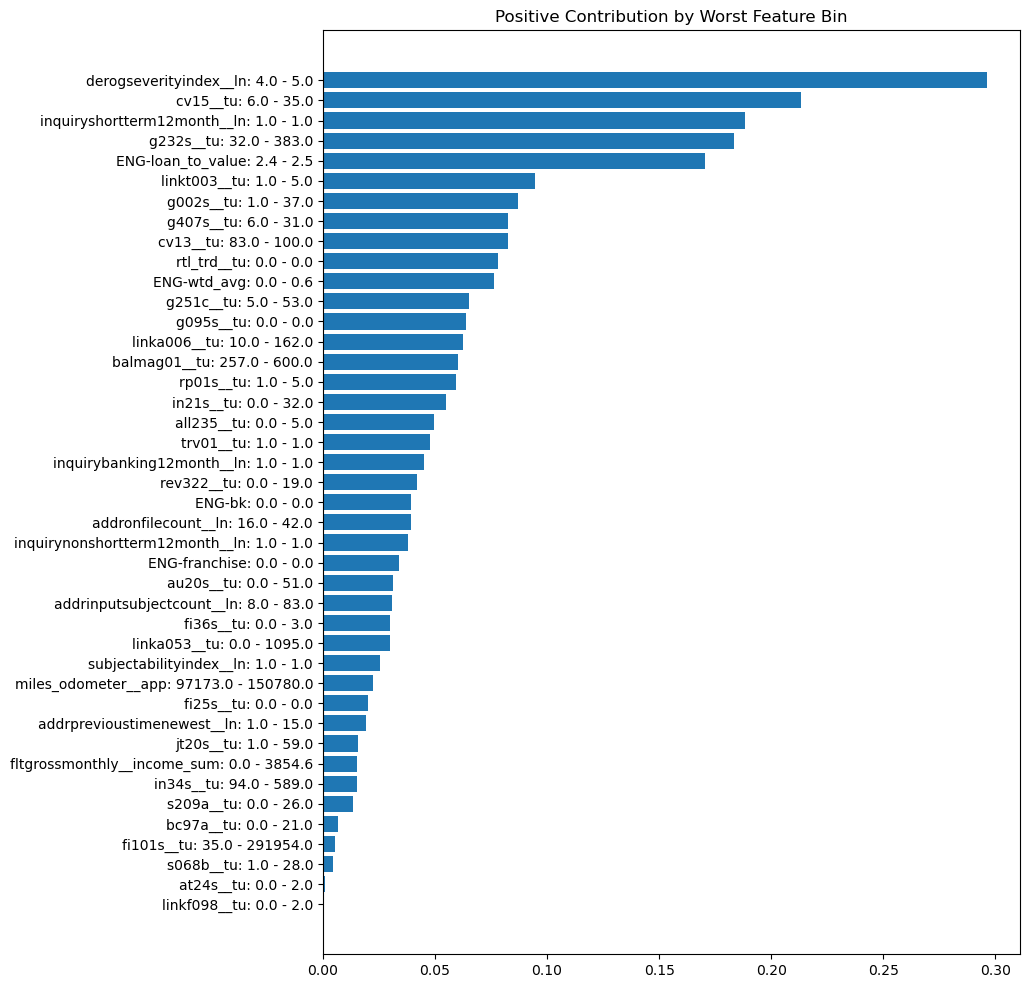

In [69]:
# plot
df_identity_sub['label'] = df_identity_sub.apply(
    lambda x: f"{x['feature'].split('_binned')[0]}: {x['min']:0.1f} - {x['max']:0.1f}",
    axis=1,
)

# plot
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)
x = df_identity_sub['label']
y = df_identity_sub['contribution']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Positive Contribution by Worst Feature Bin')
ax.barh(x, y)

# save
str_filename = 'worst_bin.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()